In [8]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [9]:
learning_rate = 3e-4
batch_size = 32
epochs = 2
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} deivce")

Using mps deivce


In [10]:
cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std = [0.2470, 0.2435, 0.2615]

train_transform = v2.Compose([
    v2.ToImage(),
    v2.RandomCrop(32, padding=4),
    v2.RandomHorizontalFlip(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=cifar_mean, std=cifar_std)
])

test_trasfrom = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=cifar_mean, std=cifar_std)
])

training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_trasfrom
)

training_dataloader = DataLoader(training_data, batch_size=32)
test_dataloader = DataLoader(test_data, batch_size=32)

In [11]:
class ResidualNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn5 = nn.BatchNorm2d(64)
        self.conv6 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn6 = nn.BatchNorm2d(64)
        self.conv7 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn7 = nn.BatchNorm2d(64) # Output 16

        self.prj1 = nn.Conv2d(64, 128, 1, 2)
        self.bnp1 = nn.BatchNorm2d(128)

        self.conv8 = nn.Conv2d(64, 128, 4, 2, 1)
        self.bn8 = nn.BatchNorm2d(128)
        self.conv9 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn9 = nn.BatchNorm2d(128)
        self.conv10 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn10 = nn.BatchNorm2d(128)
        self.conv11 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn11 = nn.BatchNorm2d(128)
        self.conv12 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn12 = nn.BatchNorm2d(128)
        self.conv13 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn13 = nn.BatchNorm2d(128)
        self.conv14 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn14 = nn.BatchNorm2d(128)
        self.conv15 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn15 = nn.BatchNorm2d(128)

        self.prj2 = nn.Conv2d(128, 256, 1, 2)
        self.bnp2 = nn.BatchNorm2d(256)

        self.conv16 = nn.Conv2d(128, 256, 4, 2, 1)
        self.bn16 = nn.BatchNorm2d(256)
        self.conv17 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn17 = nn.BatchNorm2d(256)
        self.conv18 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn18 = nn.BatchNorm2d(256)
        self.conv19 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn19 = nn.BatchNorm2d(256)
        self.conv20 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn20 = nn.BatchNorm2d(256)
        self.conv21 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn21 = nn.BatchNorm2d(256)
        self.conv22 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn22 = nn.BatchNorm2d(256)
        self.conv23 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn23 = nn.BatchNorm2d(256)
        self.conv24 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn24 = nn.BatchNorm2d(256)
        self.conv25 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn25 = nn.BatchNorm2d(256)
        self.conv26 = nn.Conv2d(256, 256, 3, 1, 1)
        self.bn26 = nn.BatchNorm2d(256)
        self.conv27 = nn.Conv2d(256, 256, 3, 1, 1) # Output 1
        self.bn27 = nn.BatchNorm2d(256)

        self.fc = nn.Linear(256, 10)


    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = x + self.bn3(self.conv3(F.relu(self.bn2(self.conv2(x)))))
        x = x + self.bn5(self.conv5(F.relu(self.bn4(self.conv4(x)))))
        x = x + self.bn7(self.conv7(F.relu(self.bn6(self.conv6(x)))))

        x = self.bn9(self.conv9(F.relu(self.bn8(self.conv8(x))))) + self.bnp1(self.prj1(x))
        x = x + self.bn11(self.conv11(F.relu(self.bn10(self.conv10(x)))))
        x = x + self.bn13(self.conv13(F.relu(self.bn12(self.conv12(x)))))
        x = x + self.bn15(self.conv15(F.relu(self.bn14(self.conv14(x)))))

        x = self.bn17(self.conv17(F.relu(self.bn16(self.conv16(x))))) + self.bnp2(self.prj2(x))
        x = x + self.bn19(self.conv19(F.relu(self.bn18(self.conv18(x)))))
        x = x + self.bn21(self.conv21(F.relu(self.bn20(self.conv20(x)))))
        x = x + self.bn23(self.conv23(F.relu(self.bn22(self.conv22(x)))))
        x = x + self.bn25(self.conv25(F.relu(self.bn24(self.conv24(x)))))
        x = x + self.bn27(self.conv27(F.relu(self.bn26(self.conv26(x)))))

        x = torch.flatten(F.avg_pool2d(x, 8), 1)
        logits = self.fc(x)
        return logits


In [12]:
def train_loop(dataloader, model, loss_fn, optimizer, loss_values):
    size = len(dataloader.dataset)
    model.to(device)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_values.append(loss.item())

        if batch % 100 == 0:
            loss, curr = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f} [{curr:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred=model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct)::>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [13]:
loss_fn = nn.CrossEntropyLoss()
model = ResidualNet()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_values = []

for e in range(epochs):
    print(f"Epoch {e+1}\n-----------------------------------")
    train_loop(training_dataloader, model, loss_fn, optimizer, loss_values)
    test_loop(test_dataloader, model, loss_fn)
print("Done")

Epoch 1
-----------------------------------
loss: 2.280737 [   32/50000]
loss: 1.893456 [ 3232/50000]


KeyboardInterrupt: 

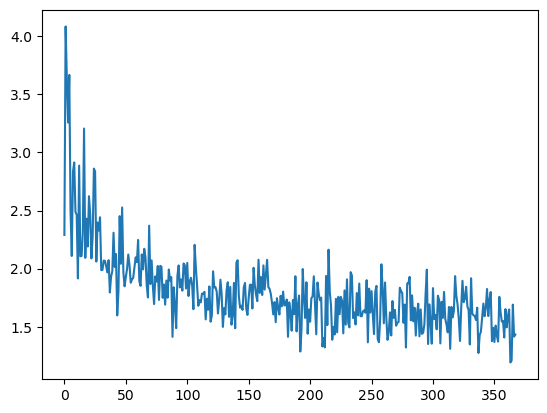

In [ ]:
plt.plot(loss_values)

In [32]:

cifar_mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
cifar_std = torch.tensor([0.2470, 0.2435, 0.2615]).view(3,1,1)

def denormalize(x):
    return x * cifar_std + cifar_mean

In [33]:
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# hook các layer muốn visualize
model.conv1.register_forward_hook(get_activation("conv1"))
model.conv8.register_forward_hook(get_activation("conv8"))
model.conv16.register_forward_hook(get_activation("conv16"))

In [50]:
model.eval()

images, labels = next(iter(test_dataloader))

image = images[17].to(device)

with torch.no_grad():
    logits = model(image.unsqueeze(0))


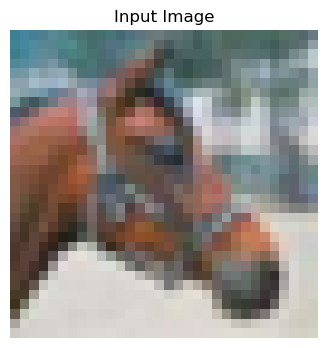

In [ ]:

img = denormalize(image.cpu())

img = img.permute(1,2,0)

img = torch.clamp(img, 0, 1)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()


In [52]:
def visualize_feature_maps(feature_map, title, num_maps=16):

    feature_map = feature_map[0]

    fig, axes = plt.subplots(4, 4, figsize=(8,8))

    for i, ax in enumerate(axes.flat):

        if i >= num_maps:
            break

        fmap = feature_map[i].cpu()

        ax.imshow(fmap, cmap="gray")

        ax.axis("off")

    plt.suptitle(title)

    plt.show()


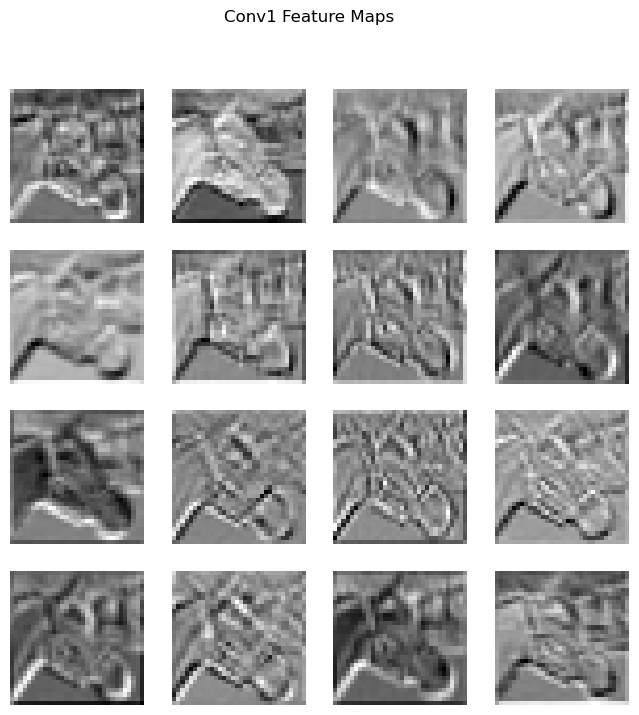

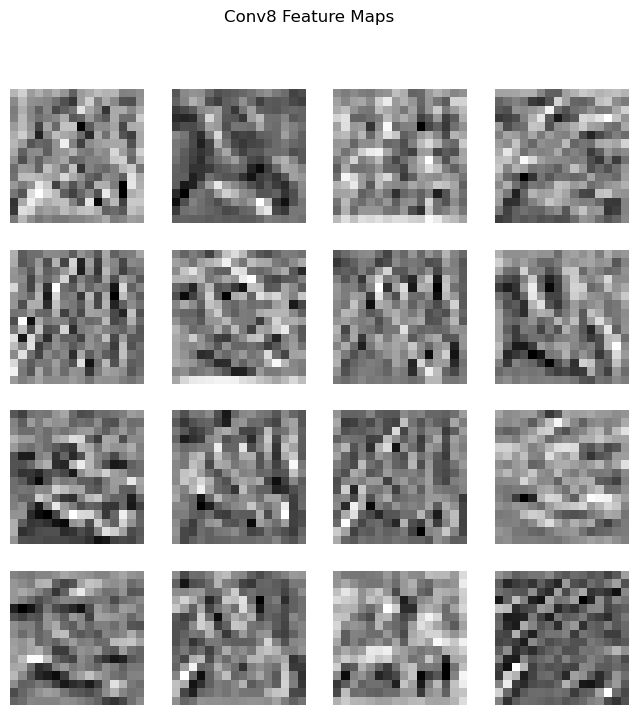

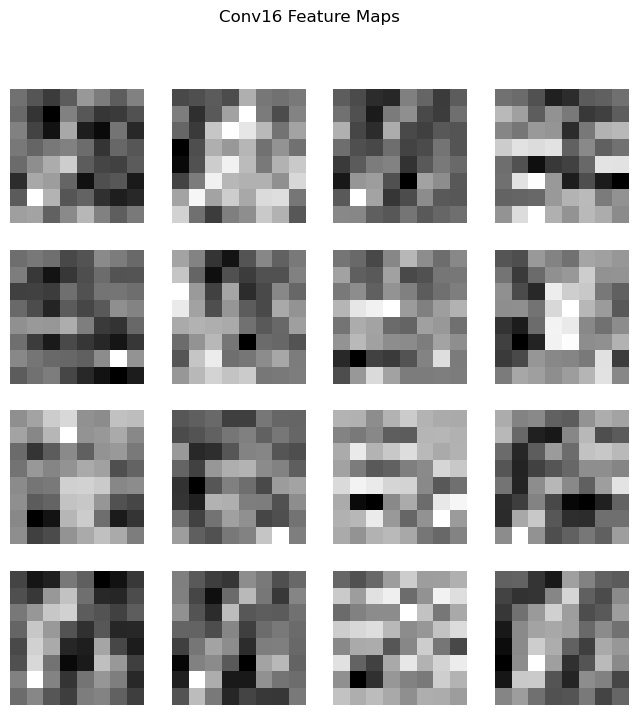

In [53]:
visualize_feature_maps(
    activation["conv1"],
    "Conv1 Feature Maps"
)

visualize_feature_maps(
    activation["conv8"],
    "Conv8 Feature Maps"
)

visualize_feature_maps(
    activation["conv16"],
    "Conv16 Feature Maps"
)